In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Advanced Analytics Started")

Advanced Analytics Started


In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

nav['date'] = pd.to_datetime(
    nav['date']
)

nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
var_results = (
    nav.groupby('amfi_code')['daily_return']
       .apply(
           lambda x: np.percentile(
               x.dropna(),
               5
           )
       )
)

var_results = var_results.to_frame(
    'VaR_95'
)

var_results.head()

,VaR_95
amfi_code,
100016,-0.014364
100025,-0.003793
100033,-0.019034
101206,-0.013282
101207,-0.026021


In [4]:
transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [5]:
transactions['cohort_month'] = (
    transactions['transaction_date']
    .dt.to_period('M')
)

cohort = (
    transactions
    .groupby('cohort_month')
    ['investor_id']
    .nunique()
)

cohort.head()

cohort_month
2024-01    1577
2024-02    1530
2024-03    1592
2024-04    1558
2024-05    1551
Freq: M, Name: investor_id, dtype: int64

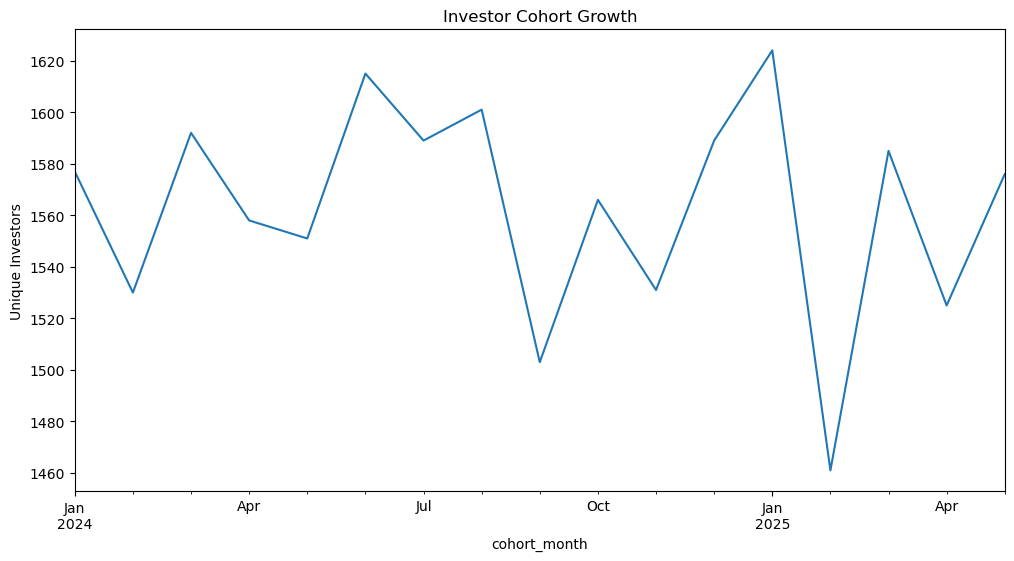

In [6]:
plt.figure(figsize=(12,6))

cohort.plot()

plt.title(
    "Investor Cohort Growth"
)

plt.ylabel(
    "Unique Investors"
)

plt.show()

In [7]:
performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
def recommend_funds(risk_level):

    if risk_level == "Low":

        return performance[
            performance['category']
            == 'Large Cap'
        ][[
            'scheme_name',
            'return_3yr_pct'
        ]].head(5)

    elif risk_level == "Medium":

        return performance[
            performance['category']
            == 'Mid Cap'
        ][[
            'scheme_name',
            'return_3yr_pct'
        ]].head(5)

    else:

        return performance[
            performance['category']
            == 'Small Cap'
        ][[
            'scheme_name',
            'return_3yr_pct'
        ]].head(5)

recommend_funds("High")

,scheme_name,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,23.14
17,Nippon India Small Cap Fund - Regular - Growth,20.15
27,Axis Small Cap Fund - Regular - Growth,20.98
29,ABSL Small Cap Fund - Regular - Growth,22.38
